In [40]:
!pip install dice_ml

In [41]:
import json
import pandas as pd
import os
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import joblib
import shap
import dice_ml
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from sklearn.calibration import CalibratedClassifierCV

In [42]:
X_train= pd.read_csv("/kaggle/input/datasets/prahazra/employee-data-processed/X_train_final.csv")
x_test= pd.read_csv("/kaggle/input/datasets/prahazra/employee-data-processed/X_test_final.csv")
x_test.drop(columns=['Unnamed: 0'], inplace= True)

Y_train= pd.read_csv("/kaggle/input/datasets/prahazra/employee-data-processed/y_train_final.csv").squeeze()
y_test= pd.read_csv("/kaggle/input/datasets/prahazra/employee-data-processed/y_test_final.csv")
y_test.drop(columns=['Unnamed: 0'], inplace= True)
y_test.squeeze()

0      0
1      0
2      1
3      1
4      0
      ..
289    0
290    0
291    0
292    0
293    0
Name: Attrition, Length: 294, dtype: int64

In [43]:
def load_params(file_path):
    with open(file_path, "r") as f:
        params_dict = json.load(f)
    print(f"Successfully loaded from: {file_path}")
    return params_dict

LR_params= load_params("/kaggle/input/notebooks/prahazra/model-optimization-ea/LR_params.json")
RF_params= load_params("/kaggle/input/notebooks/prahazra/model-optimization-ea/RF_params.json")
GB_params= load_params("/kaggle/input/notebooks/prahazra/model-optimization-ea/GB_params.json")
XGB_params= load_params("/kaggle/input/notebooks/prahazra/model-optimization-ea/XGB_params.json")

Successfully loaded from: /kaggle/input/notebooks/prahazra/model-optimization-ea/LR_params.json
Successfully loaded from: /kaggle/input/notebooks/prahazra/model-optimization-ea/RF_params.json
Successfully loaded from: /kaggle/input/notebooks/prahazra/model-optimization-ea/GB_params.json
Successfully loaded from: /kaggle/input/notebooks/prahazra/model-optimization-ea/XGB_params.json


In [44]:
LR_params

{'penalty': 'l2',
 'C': 8.614054687635518,
 'tol': 0.00022507696300949772,
 'solver': 'lbfgs',
 'max_iter': 79}

In [45]:
LR_classifier= LogisticRegression(**LR_params, random_state = 0)
LR_classifier.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=8.614054687635518, max_iter=79, random_state=0,
                   tol=0.00022507696300949772)

In [46]:
RF_params['max_features']= RF_params.pop('max_features_option')
RF_params

{'n_estimators': 283,
 'criterion': 'gini',
 'max_depth': 10,
 'min_samples_split': 10,
 'bootstrap': False,
 'class_weight': 'balanced_subsample',
 'max_features': 'log2'}

In [47]:
RF_classifier= RandomForestClassifier(**RF_params, random_state=0)
RF_classifier.fit(X_train, Y_train)

RandomForestClassifier(bootstrap=False, class_weight='balanced_subsample',
                       max_depth=10, max_features='log2', min_samples_split=10,
                       n_estimators=283, random_state=0)

In [48]:
GB_params['max_features']= GB_params.pop('max_features_option')
GB_params

{'loss': 'exponential',
 'learning_rate': 0.02671139783105934,
 'n_estimators': 295,
 'criterion': 'friedman_mse',
 'min_samples_split': 2,
 'min_impurity_decrease': 0.08653117521028135,
 'max_depth': 10,
 'max_features': 'log2'}

In [49]:
GB_classifier= GradientBoostingClassifier(**GB_params, random_state = 0)
GB_classifier.fit(X_train, Y_train)

GradientBoostingClassifier(learning_rate=0.02671139783105934,
                           loss='exponential', max_depth=10,
                           max_features='log2',
                           min_impurity_decrease=0.08653117521028135,
                           n_estimators=295, random_state=0)

In [50]:
XGB_params

{'n_estimators': 363,
 'max_depth': 11,
 'grow_policy': 'lossguide',
 'learning_rate': 0.051843566695625815,
 'booster': 'gbtree',
 'gamma': 0.06945206656210001,
 'min_child_weight': 2}

In [51]:
XGB_classifier= XGBClassifier(**XGB_params)
XGB_classifier.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.06945206656210001,
              grow_policy='lossguide', importance_type=None,
              interaction_constraints=None, learning_rate=0.051843566695625815,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=11, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=363, n_jobs=None,
              num_parallel_tree=None, ...)

In [52]:
LR_pred= LR_classifier.predict(x_test)
RF_pred= RF_classifier.predict(x_test)
GB_pred= GB_classifier.predict(x_test)
XGB_pred= XGB_classifier.predict(x_test)

predictions_map = {
    'Logistic Regression': LR_pred,
    'Random Forest': RF_pred,
    'Gradient Boosting': GB_pred,
    'XGBoost': XGB_pred
}

performance_data = []

for model_name, y_pred in predictions_map.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    performance_data.append({
        'Model': model_name,
        'Accuracy': f"{accuracy * 100:.2f}%",
        'Precision': f"{precision * 100:.2f}%",
        'Recall': f"{recall * 100:.2f}%",
        'F1-Score': f"{f1 * 100:.2f}%"
    })

performance_df = pd.DataFrame(performance_data)
print(performance_df)

                 Model Accuracy Precision  Recall F1-Score
0  Logistic Regression   74.49%    34.44%  65.96%   45.26%
1        Random Forest   84.69%    58.33%  14.89%   23.73%
2    Gradient Boosting   85.37%    66.67%  17.02%   27.12%
3              XGBoost   87.07%    73.68%  29.79%   42.42%


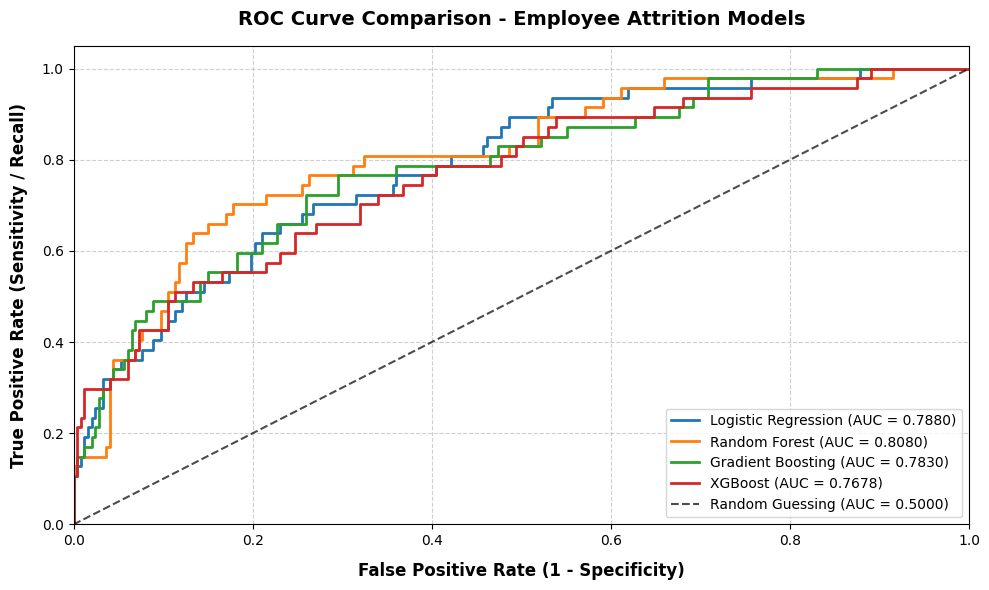

In [53]:


# 1. Map your models into a clean dictionary
# Ensure your model variables match these names exactly in your environment
models = {
    'Logistic Regression': LR_classifier,
    'Random Forest': RF_classifier,
    'Gradient Boosting': GB_classifier,
    'XGBoost': XGB_classifier
}

plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_probs = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5000)', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('ROC Curve Comparison - Employee Attrition Models', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10, frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Hence, based on all the metrices and the auc score we should use the Random Forest model.

In [54]:
final_classifier= RandomForestClassifier(**RF_params, random_state=0)
rf_calibrated = CalibratedClassifierCV(estimator=final_classifier, method='isotonic', cv=5)
rf_calibrated.fit(X_train, Y_train)

CalibratedClassifierCV(cv=5,
                       estimator=RandomForestClassifier(bootstrap=False,
                                                        class_weight='balanced_subsample',
                                                        max_depth=10,
                                                        max_features='log2',
                                                        min_samples_split=10,
                                                        n_estimators=283,
                                                        random_state=0),
                       method='isotonic')

In [55]:
y_pred= rf_calibrated.predict(x_test)
report= classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.86      0.98      0.91       247
           1       0.57      0.17      0.26        47

    accuracy                           0.85       294
   macro avg       0.72      0.57      0.59       294
weighted avg       0.81      0.85      0.81       294



In [56]:
joblib.dump(rf_calibrated, 'classifier.pkl')

['classifier.pkl']

# Model Explainability

## Feature Importance Graph

In [57]:
importances= RF_classifier.feature_importances_
preprocessor = joblib.load("/kaggle/input/datasets/prahazra/preprocessor-ea/preprocessor_pipeline.pkl")
encoded_columns = preprocessor.get_feature_names_out()
feature_df = pd.DataFrame(
    {"Feature": encoded_columns, "Importance": importances}
).sort_values(by="Importance", ascending=True)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code o

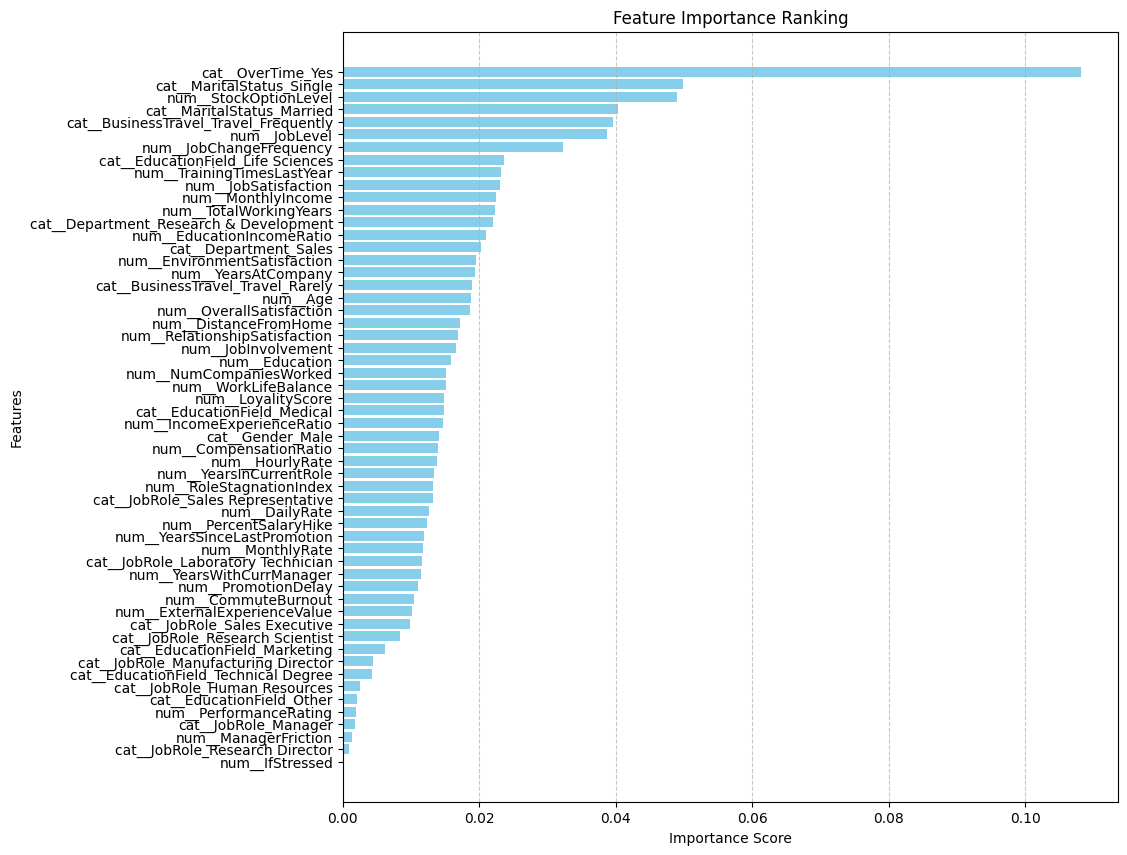

In [58]:
plt.figure(figsize=(10, 10))
plt.barh(feature_df["Feature"], feature_df["Importance"], color="skyblue")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance Ranking")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

Hence, we can see that working overtime has the highest impact on attrition aong all the other features.

## SHAP value analysis

In [59]:
explainer= shap.TreeExplainer(RF_classifier)
shap_values = explainer(x_test)
shap_values.feature_names= list(encoded_columns)
shap_values.feature_names = [f.split('_', 1)[-1] for f in shap_values.feature_names]

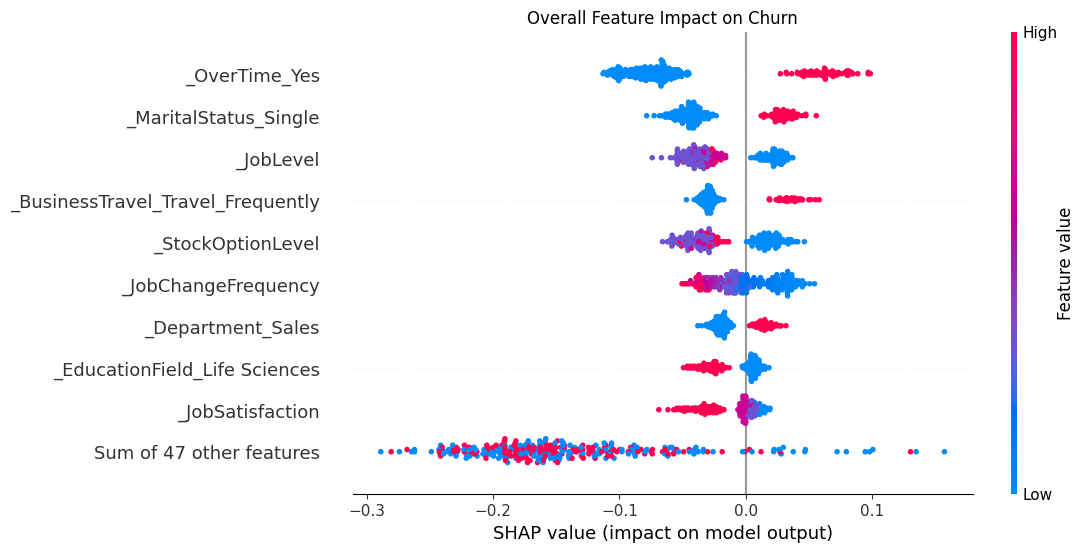

In [60]:
plt.title("Overall Feature Impact on Churn")
shap.plots.beeswarm(shap_values[:, :, 1], max_display=10, show=False, plot_size=(10, 6))
plt.show()

Hence,
- Working overtime (_OverTime_Yes) and being single (_MaritalStatus_Single) are the strongest drivers that directly increase the risk of attrition.
-  Higher job levels (JobLevel) and having more stock options (_StockOptionLevel) heavily protect against attrition, making these employees likely to stay.
-  Low job and overall satisfaction levels (JobSatisfaction, _OverallSatisfaction) along with frequent business travel significantly push employees toward leaving the company.

## PDP

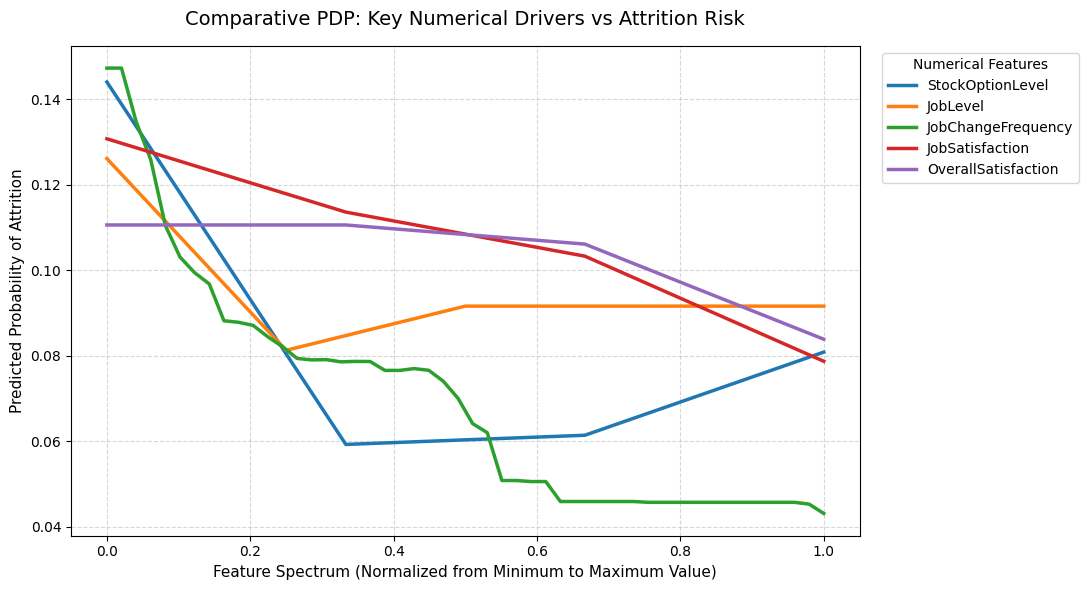

In [61]:
numerical_features = [
    'StockOptionLevel', 
    'JobLevel', 
    'JobChangeFrequency', 
    'JobSatisfaction', 
    'OverallSatisfaction'
]

plt.figure(figsize=(11, 6), dpi=100)

for col in numerical_features:
    pdp_results = partial_dependence(
        estimator=model, 
        X=x_test, 
        features=[col], 
        kind="average", 
        grid_resolution=50
    )
    
    y_values = pdp_results['average']
    x_raw = pdp_results['grid_values'][0]
    
    if y_values.ndim > 1:
        y_values = y_values[1] if y_values.shape[0] > 1 else y_values[0]
    x_normalized = (x_raw - x_raw.min()) / (x_raw.max() - x_raw.min()) if x_raw.max() > x_raw.min() else x_raw
    plt.plot(x_normalized, y_values, label=col, linewidth=2.5)

plt.title("Comparative PDP: Key Numerical Drivers vs Attrition Risk", fontsize=14, pad=15)
plt.xlabel("Feature Spectrum (Normalized from Minimum to Maximum Value)", fontsize=11)
plt.ylabel("Predicted Probability of Attrition", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Numerical Features", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


- Moving past the lowest values for job change frequency and stock options yields the sharpest overall drop in employee attrition risk.
-  Higher individual job satisfaction and overall satisfaction scores steadily and consistently decrease the probability of turnover across their entire ranges.
-  Attrition risk peaks severely at the lowest job levels and stock tiers, but rapidly stabilizes once employees progress past an initial baseline threshold.

In [62]:
import dice_ml
import pandas as pd

def generate_attrition_counterfactual(
    model, 
    train_df, 
    query_instance, 
    continuous_features, 
    outcome_name='Attrition',
    total_CFs=3,
    features_to_vary='all'
):
    # 1. Initialize the dataset container
    dice_data = dice_ml.Data(
        dataframe=train_df, 
        continuous_features=continuous_features, 
        outcome_name=outcome_name
    )
    
    # 2. Wrap your machine learning model
    dice_model = dice_ml.Model(
        model=model, 
        backend="sklearn",
        model_type="classifier" 
    )
    
    # 🔍 FIX: Intercept DiCE model prediction calls to strip out 'object' types for XGBoost
    original_get_output = dice_model.get_output
    
    def custom_get_output(input_instance, model_score=True):
        # Convert any column that DiCE decoded as 'object' or string back into numeric float/int
        if isinstance(input_instance, pd.DataFrame):
            for col in input_instance.columns:
                if input_instance[col].dtype == 'object':
                    # Convert to numeric, turning strings like '0.0' or '1' into integers/floats
                    input_instance[col] = pd.to_numeric(input_instance[col], errors='coerce').fillna(0)
                    # Convert float representation back to int if appropriate for the one-hot columns
                    input_instance[col] = input_instance[col].astype(int)
        return original_get_output(input_instance, model_score=model_score)
    
    # Apply the custom wrapper function
    dice_model.get_output = custom_get_output

    # 3. Instantiate the explainer using the genetic algorithm
    explainer = dice_ml.Dice(
        dice_data, 
        dice_model, 
        method="genetic"
    )
    
    print("Generating scenarios to achieve the opposite prediction outcome...")
    dice_exp = explainer.generate_counterfactuals(
        query_instance, 
        total_CFs=total_CFs, 
        desired_class="opposite",
        features_to_vary=features_to_vary
    )
    
    # 5. Render visualization
    dice_exp.visualize_as_dataframe(show_only_changes=True)
    
    return dice_exp


In [63]:
# 1. Combine training inputs and targets into a local DataFrame
complete_train_df = X_train.copy()
complete_train_df['Attrition'] = Y_train

# 2. Dynamically determine continuous features present in your final dataframe
# This eliminates human error and filters out one-hot columns and the target column
continuous_features_dynamic = [
    col for col in complete_train_df.columns 
    if col != 'Attrition' and not any(col.startswith(pfx) for pfx in ['BusinessTravel_', 'Department_', 'EducationField_', 'JobRole_'])
]

# 3. Dynamically filter features_to_vary to ensure only existing columns are passed
requested_vary = [
    'JobLevel', 'MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'StockOptionLevel',
    'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'OverTime_Yes'
]
features_to_vary_dynamic = [col for col in requested_vary if col in complete_train_df.columns]

# 4. Trigger your function safely with the dynamic lists
cf_explanations = generate_attrition_counterfactual(
    model=model,
    train_df=complete_train_df,
    query_instance=x_test.iloc[[199]],  # Use double brackets [[]] to preserve DataFrame structure
    continuous_features=continuous_features_dynamic,
    outcome_name='Attrition',
    total_CFs=3,
    features_to_vary=features_to_vary_dynamic
)


Generating scenarios to achieve the opposite prediction outcome...


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_genetic.py:285: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  query_instance_df_dummies[col] = 0
/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_genetic.py:285: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  query_instance_df_dummies[col] = 0
/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_genetic.py:285: PerformanceWarning: DataFrame is highly fragmented.  This is usua

Query instance (original outcome : 0)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Attrition
0,0.430989,0.248221,-0.526353,-0.874703,-1.570674,1.426485,-1.026432,-0.947066,-1.530771,-0.929888,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0



Diverse Counterfactual set (new outcome: 1)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Attrition
0,-,-,-,-,-,-,-,-,-,-1.160188,...,-,-,-,-,-,-,-,-,-,1.0
0,-,-,-,-,-,-,-,-,-,-1.160188,...,-,-,-,-,-,-,-,-,-,1.0
0,-,-,-,-,-,-,-,-,-,-1.160188,...,-,-,-,-,-,-,-,-,-,1.0


This function will provide individual level explanation of which features to change to retaine an employee who is about to leave.